<a href="https://colab.research.google.com/github/anlin123-coder/Supervised-Learning/blob/main/Supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data=pd.read_csv('/content/insurance.csv')

In [5]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
data.isna()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [7]:
data.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


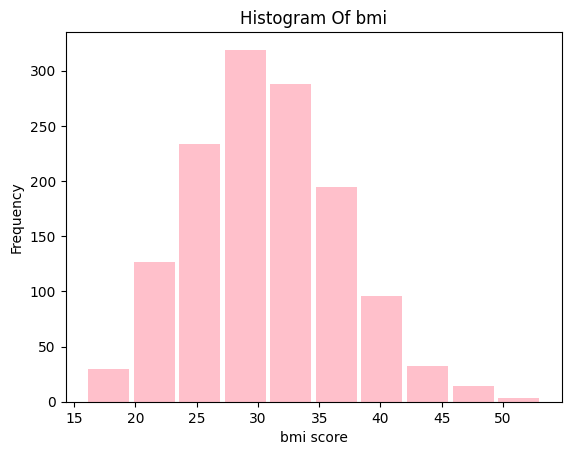

In [9]:
plt.hist(data['bmi'],color='pink',rwidth=0.9)
plt.title('Histogram Of bmi')
plt.xlabel('bmi score')
plt.ylabel('Frequency')
plt.show()

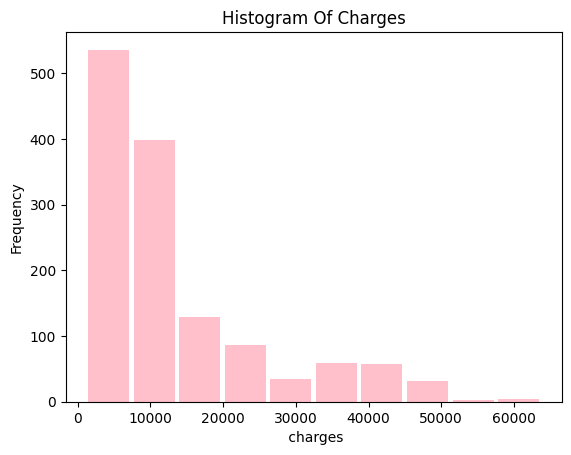

In [10]:
plt.hist(data['charges'],color='pink',rwidth=0.9)
plt.title('Histogram Of Charges')
plt.xlabel(' charges')
plt.ylabel('Frequency')
plt.show()

<Axes: >

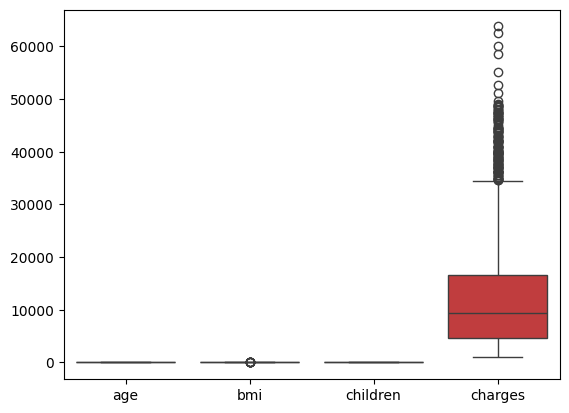

In [11]:
sns.boxplot(data)

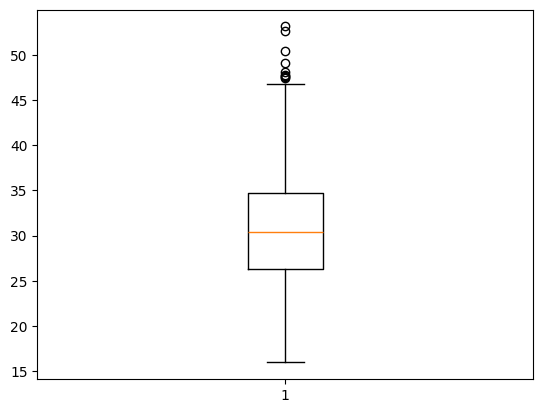

In [12]:
plt.boxplot(data['bmi'])
plt.show()

#**handling outliers in bmi col**

In [13]:
q1=data['bmi'].quantile(0.25)
q2=data['bmi'].quantile(0.5)
q3=data['bmi'].quantile(0.75)
iqr=q3-q1
lower=q1-(1.5*iqr)
upper=q3+(1.5*iqr)

In [14]:
print(q1,q2,q3,iqr,lower,upper)

26.29625 30.4 34.69375 8.3975 13.7 47.290000000000006


In [15]:
data['bmi']=np.where(data['bmi']>upper,upper,np.where(data['bmi']<lower,lower,data['bmi']))

In [16]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


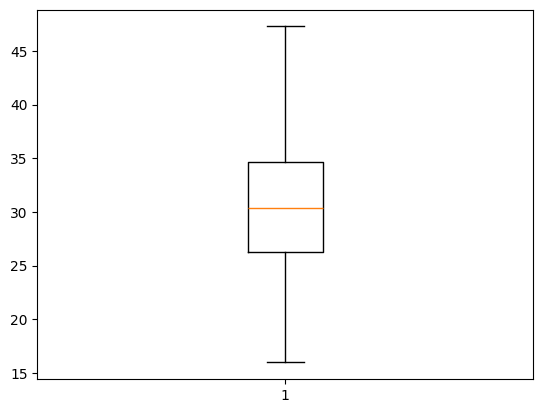

In [17]:
plt.boxplot(data['bmi'])
plt.show()

In [18]:
num_data=data.select_dtypes(['int','float'])

In [19]:
num_data.corr()

,age,bmi,children,charges
age,1.000000,0.111930,0.042469,0.299008
bmi,0.111930,1.000000,0.013700,0.198997
children,0.042469,0.013700,1.000000,0.067998
charges,0.299008,0.198997,0.067998,1.000000


#Encoding

In [20]:
data['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [21]:
#Label Encoding sex and smoker
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
data['sex']=le1.fit_transform(data['sex'])

In [22]:
le2=LabelEncoder()
data['smoker']=le2.fit_transform(data['smoker'])


In [23]:
data =pd.get_dummies(data,columns=['region'],dtype='int')

In [24]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [25]:
x=data.drop('charges',axis=1)
y=data['charges']

In [26]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [28]:
y_train

,charges
601,9174.13565
1095,4561.18850
628,11365.95200
950,11534.87265
1285,8534.67180
...,...
182,4005.42250
872,5966.88740
555,3847.67400
170,13405.39030


In [29]:
x_test

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
384,44,1,22.135,2,0,1,0,0,0
893,47,1,38.940,2,1,0,0,1,0
58,53,0,22.880,1,1,0,0,1,0
855,20,0,29.600,0,0,0,0,0,1
858,25,0,32.230,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
556,46,1,33.440,1,0,1,0,0,0
229,47,1,25.460,2,0,1,0,0,0
1155,36,0,22.135,3,0,1,0,0,0
1315,18,1,28.310,1,0,1,0,0,0


In [30]:
x_train

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
601,51,1,31.635,0,0,0,1,0,0
1095,18,0,31.350,4,0,1,0,0,0
628,58,1,38.000,0,0,0,0,0,1
950,57,1,18.335,0,0,1,0,0,0
1285,47,0,24.320,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...
182,22,1,19.950,3,0,1,0,0,0
872,42,1,24.860,0,0,0,0,1,0
555,28,1,23.800,2,0,0,0,0,1
170,63,1,41.470,0,0,0,0,1,0


In [31]:
y_test

,charges
384,8302.53565
893,44202.65360
58,23244.79020
855,1875.34400
858,18218.16139
...,...
556,8334.58960
229,9225.25640
1155,7228.21565
1315,11272.33139


In [32]:
#same data for everyone
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
x_train

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
560,46,0,19.950,2,0,0,1,0,0
1285,47,0,24.320,0,0,1,0,0,0
1142,52,0,24.860,0,0,0,0,1,0
969,39,0,34.320,5,0,0,0,1,0
486,54,0,21.470,3,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1095,18,0,31.350,4,0,1,0,0,0
1130,39,0,23.870,5,0,0,0,1,0
1294,58,1,25.175,0,0,1,0,0,0
860,37,0,47.290,2,1,0,0,0,1


#linear Regression

In [34]:
from sklearn.linear_model import LinearRegression
model =LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [35]:
model.fit(x_train,y_train)

LinearRegression()

In [36]:
y_pred=model.predict(x_train)

In [37]:
y_pred

array([ 7048.11950104,  8320.83813461,  9126.56289142, ...,
       11422.38390318, 37273.79730616, 11449.45733607])

In [38]:
y_pred=model.predict(x_test)

In [39]:
y_pred

array([ 8947.21421314,  7072.6024192 , 36831.61019387,  9437.80524726,
       26993.5161127 , 10923.53870566,   149.39247085, 16935.21014727,
        1046.68538398, 11212.7589648 , 28075.63357809,  9385.18751081,
        5264.47164303, 38462.74434673, 40294.82836255, 37131.43761961,
       15287.63700758, 35931.40606523,  9100.04251957, 31444.15688703,
        3823.91157122, 10140.19638405,  2384.50518929,  7193.22768188,
       11287.04673631, 12970.46050724, 14519.59804908,  6164.8129848 ,
        9946.7489708 ,  2194.10238728,  9103.9788324 , 13076.21808366,
        4590.71114125,  3367.19341688,  4467.57752829, 13081.45181729,
        1968.25943967,  8807.03279673, 33236.40735666, 32608.935964  ,
        3901.3708395 ,  4346.46153238, 14156.17164262, 11404.20586169,
        8804.93689978, 12080.16511429,  5304.3466907 ,  3125.17671886,
       35515.2046467 ,  9193.04756245, 15853.7685424 ,  2355.05220812,
       12414.13597862,  1484.86405831, 13407.27978113, 12584.98186554,
      

In [40]:
y_test

,charges
764,9095.06825
887,5272.17580
890,29330.98315
1293,9301.89355
259,33750.29180
...,...
109,47055.53210
575,12222.89830
535,6067.12675
543,63770.42801


In [41]:
from sklearn.metrics import mean_absolute_error
mse =mean_absolute_error(y_test,y_pred)
print('mean absolute error =',mse)

mean absolute error = 4197.260290891279


In [42]:
from sklearn.metrics import mean_squared_error
mse =mean_squared_error(y_test,y_pred)
print('mean squared error =',mse)

mean squared error = 33743973.14919153


In [43]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print('r2 score =',r2)

r2 score = 0.782645740000912


#Prediction

In [44]:

age = 25
sex='male'
bmi=23.5
children=0
smoker='yes'
region='northeast'

sex =le1.fit_transform(['sex'])
smoker = le2.fit_transform(['smoker'])
region_northeast= 1 if region=='northeast' else 0
region_northwest= 1 if region=='northwest' else 0
region_southeast= 1 if region=='southeast' else 0
region_southwest= 1 if region=='southwest' else 0


In [45]:
#create input dataframe
input_data=pd.DataFrame({'age':[age],'sex':[sex],'bmi':[bmi],'children':[children],'smoker':[smoker],'region_northeast':[region_northeast],'region_northwest':[region_northwest],'region_southeast':[region_southeast],'region_southwest':[region_southwest]})

In [46]:
model.predict(input_data)

array([2396.92079883])